# **Augmented Dickey-Fuller (ADF) test**

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import os

In [16]:
# --- 1. Generate a Synthetic "Stock Price" Dataset ---
# We simulate a non-stationary Random Walk with a slight upward drift
np.random.seed(42)
days = 365 * 2
date_rng = pd.date_range(start='2023-01-01', periods=days, freq='D')

# Random noise + Drift
noise = np.random.normal(0, 1, days)
drift = 0.5
stock_price = 100 + np.cumsum(noise + drift)

df = pd.Series(stock_price, index=date_rng, name='Stock_Price')

In [17]:
# --- 2. Define a Reusable Function for Stationarity Check ---
def check_stationarity(timeseries, title):
    # A. Calculate Rolling Statistics
    window_size = 30  # 30-day moving average
    rolmean = timeseries.rolling(window=window_size).mean()
    rolstd = timeseries.rolling(window=window_size).std()

    # B. Plot Rolling Statistics
    plt.figure(figsize=(12, 5))
    plt.plot(timeseries, color='blue', label='Original Series')
    plt.plot(rolmean, color='red', label='Rolling Mean')
    plt.plot(rolstd, color='black', label='Rolling Std Dev')
    plt.legend(loc='best')
    plt.title(f'{title}: Rolling Mean & Standard Deviation')
    plt.grid(True)
    plt.show()

    # C. Perform Augmented Dickey-Fuller Test
    print(f'Results of Dickey-Fuller Test for {title}:')
    dftest = adfuller(timeseries, autolag='AIC')
    
    # Format output for readability
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput[f'Critical Value ({key})'] = value
        
    print(dfoutput)
    print("\nConclusion:")
    if dftest[1] <= 0.05:
        print("--> p-value <= 0.05: The series is STATIONARY.")
    else:
        print("--> p-value > 0.05: The series is NON-STATIONARY.")
    print("="*50)

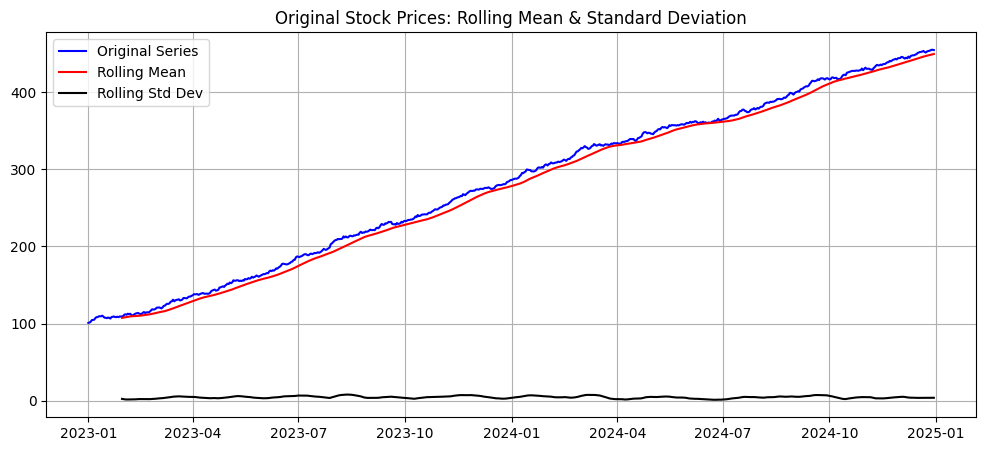

Results of Dickey-Fuller Test for Original Stock Prices:
Test Statistic                  -0.413737
p-value                          0.907780
#Lags Used                       0.000000
Number of Observations Used    729.000000
Critical Value (1%)             -3.439352
Critical Value (5%)             -2.865513
Critical Value (10%)            -2.568886
dtype: float64

Conclusion:
--> p-value > 0.05: The series is NON-STATIONARY.


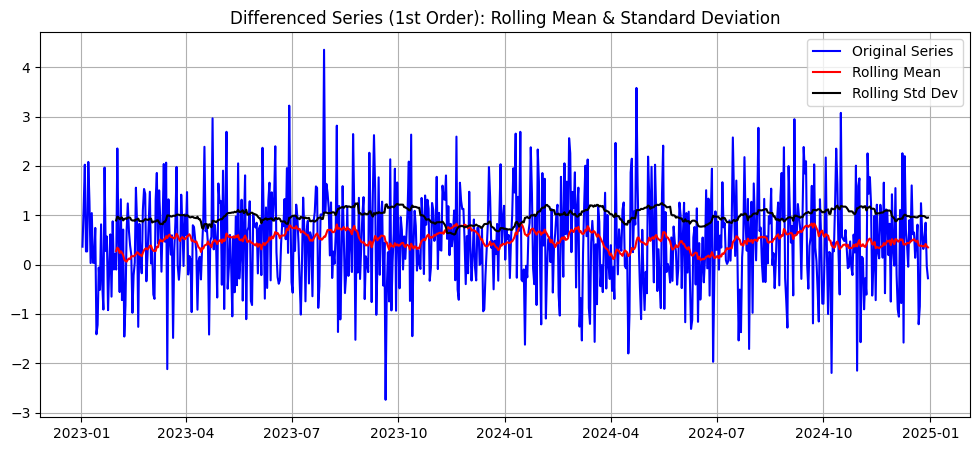

Results of Dickey-Fuller Test for Differenced Series (1st Order):
Test Statistic                 -27.669321
p-value                          0.000000
#Lags Used                       0.000000
Number of Observations Used    728.000000
Critical Value (1%)             -3.439364
Critical Value (5%)             -2.865518
Critical Value (10%)            -2.568888
dtype: float64

Conclusion:
--> p-value <= 0.05: The series is STATIONARY.


In [18]:
# --- 3. Analyze the Original Series ---
check_stationarity(df, "Original Stock Prices")

# --- 4. Apply Differencing to Make it Stationary ---
# We subtract the previous day's price from today's (Lag 1 difference)
df_diff = df.diff().dropna()

# --- 5. Analyze the Differenced Series ---
check_stationarity(df_diff, "Differenced Series (1st Order)")